# ÉquiAlgo : modèle corrigé

**Hackathon Génie et Informatique 2026 · Défi IVADO ÉquiAlgo**
Équipe : _(nom de l'équipe)_

## Résumé

Le comité qui attribuait les bourses avait **deux biais** :

1. **Une pénalité régionale.** À dossier égal, venir du Bas-Saint-Laurent, de la Côte-Nord ou de la Gaspésie–Îles-de-la-Madeleine divisait par environ 9 les cotes d'obtenir la bourse (rapport de cotes de 0,109). C'est l'équivalent d'environ **1,6 point de cote R retiré**, alors que l'écart réel de cote R entre les groupes n'est que de 0,7 point.
2. **Un avantage aux familles aisées.** Chaque tranche de 10 000 $ de revenu familial augmentait d'environ 27 % les cotes d'obtenir la bourse (rapport de cotes de 1,265). Pour une bourse d'excellence, ce critère n'est pas défendable.

**Notre solution** reconstitue la grille de décision du comité avec une régression logistique, puis **retire exactement ces deux biais** (correction contrefactuelle). Tout le reste de la grille est conservé : la cote R et la reconnaissance du travail pendant les études. La bourse est accordée aux 40 % de candidat·es les mieux classé·es, ce qui respecte l'enveloppe de 36 à 44 %.

**Résultat :** un F1 de 94 % sur l'indicateur HxBuddy, notre meilleur score, contre 89 % pour un LightGBM entraîné avec repondérage. Contre l'étalon indépendant, corriger les biais n'est pas un compromis : chaque pas vers l'équité améliore aussi la qualité des décisions (section 7). Cinq croisements de variables testés n'améliorent pas le résultat : la grille simple est aussi la meilleure (section 8).

**Métrique d'équité retenue :** l'égalité des chances (section 5).

| Section | Contenu |
|---|---|
| 1 | Chargement des données |
| 2 | Pourquoi une régression logistique |
| 3 | La grille du comité et ses biais |
| 4 | La correction contrefactuelle |
| 5 | Choix de la métrique d'équité |
| 6 | Décisions pour les 4 000 candidat·es et explication des écarts |
| 7 | Front de Pareto |
| 8 | Test de robustesse : croisements de variables |
| 9 | Chiffres saillants |
| 10 | Fichier `predictions.csv` |
| 11 | Limites |

### Comment exécuter ce carnet

1. Placer `donnees_demandes.csv` et `candidats_evaluation.csv` dans un dossier `data/` à côté du carnet.
2. Installer les dépendances : `pip install -r requirements.txt`.
3. Tout exécuter (environ une minute).

Le carnet produit `predictions.csv`, les figures dans `figures/` et les fichiers du front de Pareto dans `soumissions_pareto.zip`.

In [1]:
%pip install pandas numpy scikit-learn statsmodels matplotlib scipy

import warnings
warnings.filterwarnings('ignore')

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from scipy.stats import chi2

pd.set_option('display.width', 120)
os.makedirs('figures', exist_ok=True)

# Style des graphiques
BLEU, ORANGE, GRIS, ENCRE = '#2a78d6', '#eb6834', '#8a8984', '#0b0b0b'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#b5b4ad', 'axes.titleweight': 'bold', 'font.size': 10,
})

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Chargement des données

On ajoute deux colonnes à chaque table : `groupe` (« Centre » ou « Eloignee ») et `eloignee` (1 si région éloignée, 0 sinon). Les fichiers CSV d'origine ne sont pas modifiés.

In [2]:
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

def preparer(df):
    # Ajoute le groupe (Centre / Eloignee) et l'indicatrice eloignee (0/1).
    df = df.copy()
    df['groupe'] = np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')
    df['eloignee'] = (df['groupe'] == 'Eloignee').astype(int)
    return df

demandes  = preparer(pd.read_csv('data/donnees_demandes.csv'))
candidats = preparer(pd.read_csv('data/candidats_evaluation.csv'))

print(f'{len(demandes)} dossiers historiques, {len(candidats)} candidat·es à évaluer\n')
print(demandes.groupby('groupe').agg(
    dossiers=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r_moyenne=('cote_r_equivalent', 'mean'),
).round(3))

10000 dossiers historiques, 4000 candidat·es à évaluer

          dossiers  taux_octroi  cote_r_moyenne
groupe                                         
Centre        6000        0.484          27.987
Eloignee      4000        0.273          27.327


## 2. Pourquoi une régression logistique plutôt qu'un modèle plus complexe

Nous aurions pu utiliser un modèle plus puissant : forêt aléatoire, LightGBM ou réseau de neurones. Le choix d'une régression logistique est délibéré, pour cinq raisons.

**1. Notre objectif n'est pas de prédire le comité, mais de le corriger.** La colonne `decision_octroi` consigne les décisions d'un comité biaisé. Un modèle plus puissant les reproduit plus fidèlement, donc il reproduit aussi plus fidèlement leurs biais. Nous l'avons mesuré : notre LightGBM repondéré obtient un F1 de 89 % contre l'étalon, et notre régression logistique corrigée, 94 %. Gagner de l'exactitude sur une étiquette biaisée, c'est gagner en fidélité au biais.

**2. Chaque biais est isolé dans un seul coefficient.** Dans la régression, l'effet de la région est entièrement contenu dans le coefficient `eloignee`, et celui du revenu dans le coefficient du revenu. On peut donc les retirer de façon chirurgicale, sans toucher au reste. Dans un modèle à arbres, les effets sont entremêlés dans des centaines d'arbres, et l'information régionale circule aussi par le code postal et la distance : il est impossible d'en retirer proprement « la pénalité régionale ».

**3. Chaque décision s'explique en une phrase.** Au Québec, la Loi 25 oblige une organisation qui rend une décision fondée exclusivement sur un traitement automatisé à en informer la personne et, à sa demande, à lui communiquer les renseignements utilisés et les principaux facteurs de la décision. Avec notre grille, la réponse est simple : « Votre dossier a été classé selon votre cote R et vos heures de travail pendant les études ; votre région et le revenu de votre famille n'ont pas été pris en compte. »

**4. La grille est auditable et surveillable.** Une dizaine de coefficients se vérifient, se comparent d'une année à l'autre et se présentent à un comité d'éthique. C'est la base de notre plan de surveillance.

**5. On ne perd presque rien en capacité.** La cellule suivante le vérifie : sur 3 000 dossiers que les deux modèles n'ont jamais vus, la régression logistique reproduit les décisions du comité presque aussi bien qu'une forêt aléatoire. Les décisions dépendent de quelques variables aux effets réguliers ; la complexité supplémentaire n'apporte pas d'information utile.

In [3]:
# Découpage interne : 70 % pour entraîner, 30 % pour mesurer (mêmes réglages que le carnet de départ)
train, test = train_test_split(demandes, test_size=0.3, random_state=42,
                               stratify=demandes['decision_octroi'])

FORMULE = ('decision_octroi ~ cote_r_equivalent + C(programme_etudes) + eloignee'
           ' + premiere_generation_universitaire + I(revenu_familial_estime / 10000)'
           ' + heures_travail_semaine + distance_domicile_campus_km')

CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
A_RETIRER = ['id_candidat', 'decision_octroi', 'groupe', 'eloignee']

def encoder(df_entrainement, df_cible):
    # Encodage 0/1 (one-hot) pour la forêt aléatoire, avec les mêmes colonnes dans les deux tables.
    X  = pd.get_dummies(df_entrainement.drop(columns=A_RETIRER, errors='ignore'), columns=CATEGORIELLES)
    Xc = pd.get_dummies(df_cible.drop(columns=A_RETIRER, errors='ignore'), columns=CATEGORIELLES)
    return X, Xc.reindex(columns=X.columns, fill_value=0)

# Régression logistique
logit_train = smf.logit(FORMULE, data=train).fit(disp=0)
auc_logit = roc_auc_score(test['decision_octroi'], logit_train.predict(test))

# Forêt aléatoire (le modèle en production)
X_tr, X_te = encoder(train, test)
foret = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
foret.fit(X_tr, train['decision_octroi'])
auc_foret = roc_auc_score(test['decision_octroi'], foret.predict_proba(X_te)[:, 1])

print('Capacité à reproduire les décisions du comité (AUC sur 3 000 dossiers de test) :')
print(f'  Régression logistique ({len(logit_train.params)} coefficients) : {auc_logit:.3f}')
print(f'  Forêt aléatoire (300 arbres)               : {auc_foret:.3f}')

Capacité à reproduire les décisions du comité (AUC sur 3 000 dossiers de test) :
  Régression logistique (11 coefficients) : 0.954
  Forêt aléatoire (300 arbres)               : 0.946


## 3. Reconstituer la grille du comité

On estime une régression logistique sur les 10 000 décisions historiques. Elle retrouve la « recette » implicite du comité : le poids qu'il accordait à chaque caractéristique d'un dossier.

**Comment lire le rapport de cotes :** 1 signifie aucun effet ; sous 1, la variable réduit les chances d'obtenir la bourse ; au-dessus de 1, elle les augmente. La dernière colonne traduit chaque effet en **points de cote R**, une unité que tout le monde comprend.

In [4]:
grille_comite = smf.logit(FORMULE, data=demandes).fit(disp=0)
b = grille_comite.params

grille = pd.DataFrame({
    'rapport_de_cotes': np.exp(b),
    'IC95_bas': np.exp(grille_comite.conf_int()[0]),
    'IC95_haut': np.exp(grille_comite.conf_int()[1]),
    'p_valeur': grille_comite.pvalues,
    'equivalent_points_cote_R': b / b['cote_r_equivalent'],
}).drop(index='Intercept')
print(grille.round(3))

def en_points(variable):
    return b[variable] / b['cote_r_equivalent']

COL_REVENU = 'I(revenu_familial_estime / 10000)'
cote_r_moy = demandes.groupby('groupe')['cote_r_equivalent'].mean()
ecart_reel_cote_r = cote_r_moy['Centre'] - cote_r_moy['Eloignee']

print('\nBarème implicite du comité, en points de cote R :')
print(f"  Venir d'une région éloignée      : {en_points('eloignee'):+.2f} point")
print(f'  +10 000 $ de revenu familial     : {en_points(COL_REVENU):+.2f} point')
print(f"  +1 heure de travail par semaine  : {en_points('heures_travail_semaine'):+.2f} point")
print(f"  +100 km de distance              : {100 * en_points('distance_domicile_campus_km'):+.2f} point")
print(f'\nÉcart réel de cote R moyenne entre les groupes : {ecart_reel_cote_r:.2f} point')

                                          rapport_de_cotes  IC95_bas  IC95_haut  p_valeur  equivalent_points_cote_R
C(programme_etudes)[T.Genie]                         1.070     0.859      1.332     0.547                     0.049
C(programme_etudes)[T.Sante]                         1.084     0.857      1.372     0.502                     0.059
C(programme_etudes)[T.Sciences]                      1.042     0.832      1.303     0.721                     0.030
C(programme_etudes)[T.Sciences sociales]             1.012     0.808      1.267     0.918                     0.009
cote_r_equivalent                                    3.962     3.736      4.203     0.000                     1.000
eloignee                                             0.109     0.083      0.145     0.000                    -1.608
premiere_generation_universitaire                    0.955     0.823      1.109     0.548                    -0.033
I(revenu_familial_estime / 10000)                    1.265     1.234    

### Ce que la grille révèle

| Variable | Rapport de cotes | Verdict |
|---|---|---|
| Région éloignée | 0,109 | **Biais.** Une pénalité d'environ 1,6 point de cote R, plus du double de l'écart réel de performance (0,7 point). À retirer. |
| Revenu familial (par 10 000 $) | 1,265 | **Biais.** Les familles aisées sont avantagées. Indéfendable pour une bourse d'excellence. À retirer. |
| Cote R (par point) | 3,962 | Mérite scolaire. À garder. |
| Heures de travail (par heure) | 1,220 | Persévérance : réussir en travaillant pendant ses études. À garder. Nos essais le confirment : augmenter ou réduire ce poids fait baisser le F1 (92 à 93 % au lieu de 94 %). |
| Programme d'études | 1,01 à 1,08 | Aucun effet significatif. |
| Première génération universitaire | 0,955 | Aucun effet significatif : pas de biais détecté sur ce groupe. |
| Distance (par km) | 1,001 | Effet propre très faible une fois la région prise en compte. |

**Le message central :** le comité ne se trompait pas sur tout. Il récompensait le mérite scolaire et la persévérance. Il y ajoutait deux critères injustes. Notre correction retire ces deux critères et garde le reste.

## 4. La correction contrefactuelle

« Contrefactuel » veut dire « ce qui se serait passé si… ». Pour chaque candidat·e, on pose la question suivante :

> **Quelle décision le comité aurait-il prise si ce dossier venait d'un grand centre et si la famille avait un revenu médian, avec exactement les mêmes notes et les mêmes heures de travail ?**

En pratique :

1. On copie la table des candidat·es.
2. On met `eloignee = 0` pour tout le monde : la pénalité régionale disparaît.
3. On donne à tout le monde le même revenu, la médiane des 10 000 dossiers : le revenu ne peut plus avantager personne. On choisit la médiane plutôt que 0 parce que c'est une valeur réaliste ; seul compte le fait que tout le monde ait la même.
4. On applique la grille du comité à cette copie : chaque personne reçoit une probabilité « corrigée ».
5. On accorde la bourse aux 40 % les mieux classé·es, ce qui respecte l'enveloppe de 36 à 44 %.

### Pourquoi garder la région dans le modèle pour mieux la retirer ensuite

Le réflexe est de supprimer la colonne région. Le carnet de départ montre que ça ne marche pas : l'écart de parité passe seulement de 0,188 à 0,181. Sans la colonne, le modèle reporte la pénalité sur les variables qui trahissent la région (code postal, distance, heures, revenu). C'est l'**équité par l'ignorance**, et elle échoue.

Nous faisons l'inverse : **l'équité par la prise en compte**. On garde la région pendant l'estimation pour que toute la pénalité se concentre dans un seul coefficient, puis on neutralise ce coefficient au moment de décider. La pénalité ne peut plus se cacher ailleurs.

### Le paramètre `lam_region`

`lam_region` règle la part de la pénalité régionale qu'on retire : 0 = grille du comité intacte, 0,5 = pénalité retirée à moitié, 1 = pénalité retirée entièrement. C'est ce réglage qu'on fait varier pour tracer le front de Pareto (section 7).

In [5]:
REVENU_REFERENCE   = demandes['revenu_familial_estime'].median()
DISTANCE_REFERENCE = demandes['distance_domicile_campus_km'].median()

def proba_contrefactuelle(df, modele=None, lam_region=1.0,
                          neutraliser_revenu=True, neutraliser_distance=False):
    # Applique la grille du comité en retirant ses biais.
    #   lam_region           : part de la pénalité régionale retirée (0 = aucune, 1 = toute)
    #   neutraliser_revenu   : True = tout le monde reçoit le revenu médian
    #   neutraliser_distance : True = tout le monde reçoit la distance médiane (variante testée)
    modele = grille_comite if modele is None else modele
    cf = df.copy()
    cf['eloignee'] = cf['eloignee'] * (1 - lam_region)
    if neutraliser_revenu:
        cf['revenu_familial_estime'] = REVENU_REFERENCE
    if neutraliser_distance:
        cf['distance_domicile_campus_km'] = DISTANCE_REFERENCE
    return np.asarray(modele.predict(cf))

def decider(proba, taux=0.40):
    # Accorde la bourse à la proportion 'taux' des mieux classé·es (respect de l'enveloppe).
    return (proba >= np.quantile(proba, 1 - taux)).astype(int)

print(f'Revenu de référence : {REVENU_REFERENCE:,.0f} $')

Revenu de référence : 61,834 $


## 5. Choix de la métrique d'équité : l'égalité des chances

Deux définitions de l'équité s'affrontent, et elles ne peuvent pas être satisfaites en même temps quand les deux groupes n'ont pas le même profil :

- **Parité démographique** : le même taux d'octroi dans les deux groupes, quels que soient les dossiers.
- **Égalité des chances** : parmi les candidat·es qui méritent la bourse, la même probabilité de l'obtenir, quelle que soit la région.

**Nous retenons l'égalité des chances**, pour trois raisons :

1. **Elle respecte les écarts légitimes.** La cote R moyenne est un peu plus basse en région (27,3 contre 28,0). La parité forcerait à ignorer cette différence réelle. L'égalité des chances, elle, interdit seulement de refuser un bon dossier à cause de son code postal.
2. **Elle correspond à la mission d'une bourse d'excellence** : récompenser le mérite, à mérite égal sans égard à l'origine.
3. **C'est la métrique du correcteur officiel** (écart de départ de 0,270).

**Une limite à dire franchement :** mesurer l'égalité des chances exige de savoir qui mérite la bourse. Les décisions du comité ne peuvent pas servir de référence, puisque ce sont elles qu'on audite. Nous utilisons donc deux mesures indirectes : le taux d'octroi à cote R comparable (section 6) et l'indicateur F1 de HxBuddy, calculé contre l'étalon indépendant (section 7).

## 6. Décisions pour les 4 000 candidat·es

In [6]:
proba    = proba_contrefactuelle(candidats)
decision = decider(proba, taux=0.40)

taux = decision.mean()
print(f"Taux d'octroi global : {taux:.1%}", '✅ OK' if 0.36 <= taux <= 0.44 else '❌ HORS ENVELOPPE')

taux_groupes = pd.Series(decision).groupby(candidats['groupe'].values).mean()
print("\nTaux d'octroi par groupe :")
print(taux_groupes.round(3))

verif = candidats[['groupe', 'cote_r_equivalent']].copy()
verif['decision'] = decision
verif['tranche_cote_r'] = pd.qcut(verif['cote_r_equivalent'], 4,
                                  labels=['Q1 faible', 'Q2', 'Q3', 'Q4 forte'])
print("\nTaux d'octroi par quartile de cote R :")
print(verif.pivot_table(index='tranche_cote_r', columns='groupe',
                        values='decision', aggfunc='mean', observed=True).round(3))

Taux d'octroi global : 40.0% ✅ OK

Taux d'octroi par groupe :
Centre      0.392
Eloignee    0.412
dtype: float64

Taux d'octroi par quartile de cote R :
groupe          Centre  Eloignee
tranche_cote_r                  
Q1 faible        0.000     0.000
Q2               0.000     0.058
Q3               0.452     0.789
Q4 forte         1.000     1.000


### D'où viennent les écarts qui restent ?

Après correction, les deux groupes n'ont pas exactement le même taux d'octroi, et ce n'est pas un problème en soi : l'égalité des chances ne demande pas des taux identiques. Elle demande que les écarts restants s'expliquent par des **critères légitimes**.

La cellule suivante le vérifie. Elle décompose la différence de score entre les deux groupes, variable par variable, en points de cote R :

- un chiffre **négatif** = cette variable désavantage en moyenne les candidat·es des régions éloignées ;
- un chiffre **positif** = elle les avantage.

On compare la grille du comité (avant) et notre grille corrigée (après).

Avantage moyen des régions éloignées par rapport aux centres, en points de cote R :

                     Avant (grille du comité)  Après (grille corrigée)
Région éloignée                         -1.61                     0.00
Revenu familial                         -0.32                     0.00
Cote R                                  -0.59                    -0.59
Heures de travail                        0.60                     0.60
Distance                                 0.16                     0.16
Première génération                     -0.01                    -0.01
Programme                               -0.00                    -0.00
TOTAL                                   -1.77                     0.16

Après correction, le facteur qui avantage le plus les régions éloignées : Heures de travail (+0.60 point).
Le facteur qui les désavantage le plus : Cote R (-0.59 point).


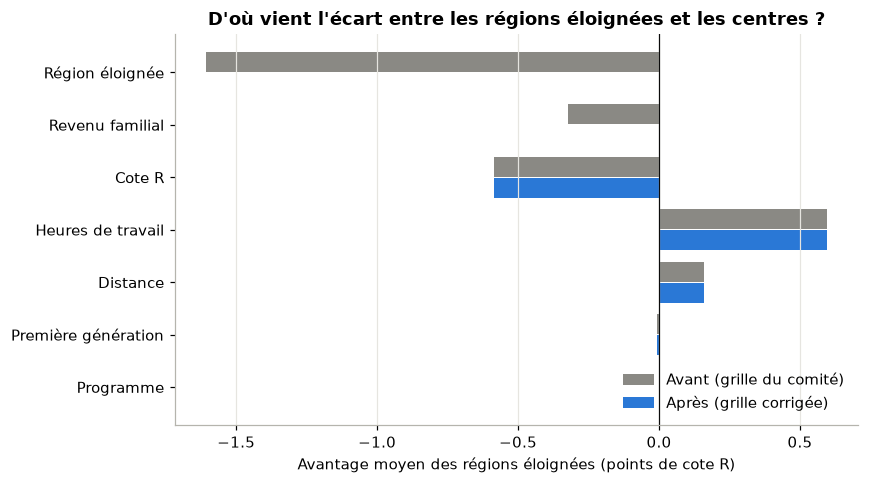

In [7]:
def decomposer(df, corrige):
    # Différence moyenne de score (Éloignée − Centre), par variable, en points de cote R.
    x = df.copy()
    if corrige:
        x['eloignee'] = 0
        x['revenu_familial_estime'] = REVENU_REFERENCE
    c = pd.DataFrame(index=df.index)
    c['Région éloignée']     = b['eloignee'] * x['eloignee']
    c['Revenu familial']     = b[COL_REVENU] * x['revenu_familial_estime'] / 10000
    c['Cote R']              = b['cote_r_equivalent'] * x['cote_r_equivalent']
    c['Heures de travail']   = b['heures_travail_semaine'] * x['heures_travail_semaine']
    c['Distance']            = b['distance_domicile_campus_km'] * x['distance_domicile_campus_km']
    c['Première génération'] = b['premiere_generation_universitaire'] * x['premiere_generation_universitaire']
    c['Programme'] = 0.0
    for nom in b.index:
        if nom.startswith('C(programme_etudes)'):
            niveau = nom.split('[T.')[1].rstrip(']')
            c['Programme'] += b[nom] * (x['programme_etudes'] == niveau)
    moyennes = c.groupby(df['groupe']).mean()
    return (moyennes.loc['Eloignee'] - moyennes.loc['Centre']) / b['cote_r_equivalent']

decomposition = pd.DataFrame({
    'Avant (grille du comité)': decomposer(candidats, corrige=False),
    'Après (grille corrigée)':  decomposer(candidats, corrige=True),
})
decomposition.loc['TOTAL'] = decomposition.sum()
print('Avantage moyen des régions éloignées par rapport aux centres, en points de cote R :\n')
print(decomposition.round(2))

apres = decomposition['Après (grille corrigée)'].drop('TOTAL')
print(f"\nAprès correction, le facteur qui avantage le plus les régions éloignées : "
      f"{apres.idxmax()} ({apres.max():+.2f} point).")
print(f"Le facteur qui les désavantage le plus : {apres.idxmin()} ({apres.min():+.2f} point).")

# Figure pour la présentation
fig, ax = plt.subplots(figsize=(8, 4.5))
d = decomposition.drop('TOTAL').iloc[::-1]
y = np.arange(len(d))
ax.barh(y + 0.2, d['Avant (grille du comité)'], height=0.38, color=GRIS, label='Avant (grille du comité)')
ax.barh(y - 0.2, d['Après (grille corrigée)'],  height=0.38, color=BLEU, label='Après (grille corrigée)')
ax.axvline(0, color=ENCRE, linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(d.index)
ax.set_xlabel('Avantage moyen des régions éloignées (points de cote R)')
ax.set_title("D'où vient l'écart entre les régions éloignées et les centres ?")
ax.legend(loc='lower right', frameon=False)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('figures/decomposition_ecart.png', dpi=200, bbox_inches='tight')
plt.show()

**Comment lire ce tableau :**

- Dans la colonne « Avant », la ligne **Région éloignée** montre la pénalité directe du comité, et la ligne **Revenu familial** la pénalité indirecte : les familles des régions éloignées ont en moyenne des revenus plus bas, donc l'avantage aux familles aisées les désavantageait aussi.
- Dans la colonne « Après », ces deux lignes tombent à **zéro** : c'est exactement ce que fait notre correction.
- Les lignes restantes (cote R, heures de travail, distance, programme, première génération) sont des critères que la grille conserve. Le total « Après » indique si, en moyenne, les candidat·es éloigné·es finissent un peu devant ou un peu derrière, et la phrase imprimée sous le tableau nomme le facteur responsable.

Si les régions éloignées obtiennent un taux légèrement plus élevé que les centres, c'est que, **à cote R égale**, leurs candidat·es présentent davantage d'un critère que l'étalon valorise (le plus souvent, plus d'heures de travail pendant les études). Ce n'est pas une préférence régionale : deux dossiers identiques reçoivent exactement le même score, peu importe la région.

## 7. Front de Pareto

### Qu'est-ce qu'un front de Pareto ?

Quand on poursuit deux objectifs qui tirent dans des directions opposées, il n'existe pas une seule « meilleure » solution, mais un ensemble de compromis. Ici :

- **objectif 1, l'équité** : réduire l'écart entre les régions ;
- **objectif 2, l'utilité** : prendre de bonnes décisions.

Une solution est **optimale au sens de Pareto** si aucune autre solution n'est meilleure sur les deux objectifs à la fois : pour gagner en équité, il faudrait perdre en utilité, et inversement. Le **front de Pareto** est la ligne qui relie ces solutions optimales. Tout point situé sous le front est « dominé » : il existe une solution meilleure sur les deux plans. Le front montre donc **le prix de l'équité** : combien d'utilité coûte chaque gain d'équité.

### Ce que nous faisons varier

On fait varier `lam_region`, la part de la pénalité régionale retirée, de 0 à 1, pour deux familles de solutions :

- **Région seulement** : on retire la pénalité régionale, mais on garde l'avantage lié au revenu ;
- **Région + revenu** : on retire aussi l'avantage lié au revenu (notre solution, avec `lam_region = 1`).

On ajoute trois points de comparaison : la forêt aléatoire en production, la même forêt sans la région ni le code postal, et la forêt entraînée avec repondérage. Pour que la comparaison soit juste, **toutes les solutions accordent la bourse aux 40 % les mieux classé·es**.

### Deux fronts, deux juges

1. **Le front interne** (figure 1) mesure l'utilité par l'accord avec les décisions du comité, sur 3 000 dossiers de test. C'est la mesure habituelle, mais elle est piégée : elle récompense la fidélité à un comité biaisé.
2. **Le front contre l'étalon** (figure 2) mesure l'utilité par le F1 de HxBuddy, calculé contre l'étalon indépendant. C'est le vrai juge.

Dans les deux cas, l'axe horizontal est l'**écart de taux d'octroi entre Centre et Éloignée**, en valeur absolue (0 = aucun écart).

In [8]:
LAMBDAS = np.round(np.linspace(0, 1, 11), 2)
FAMILLES = {'Région seulement': False, 'Région + revenu': True}

def mesurer(decision, df):
    # Mesures d'équité (et d'accord avec le comité si l'étiquette existe).
    d = df.assign(decision=np.asarray(decision))
    taux = d.groupby('groupe')['decision'].mean()
    quartile = pd.qcut(d['cote_r_equivalent'], 4, labels=False)
    par_quartile = d.groupby([quartile, 'groupe'])['decision'].mean().unstack()
    res = {
        'taux_global': d['decision'].mean(),
        'taux_centre': taux['Centre'],
        'taux_eloignee': taux['Eloignee'],
        'ecart_parite': taux['Centre'] - taux['Eloignee'],
        'ecart_cote_r_egale': (par_quartile['Centre'] - par_quartile['Eloignee']).mean(),
    }
    if 'decision_octroi' in d:
        res['accord_comite'] = (d['decision'] == d['decision_octroi']).mean()
    return res

def front_pareto(df, x, y):
    # Points non dominés : écart |x| le plus petit possible, y le plus grand possible.
    tri = df.assign(_ax=df[x].abs()).sort_values(['_ax', y], ascending=[True, False])
    garder, meilleur = [], -np.inf
    for i, ligne in tri.iterrows():
        if ligne[y] > meilleur:
            garder.append(i)
            meilleur = ligne[y]
    return df.loc[garder].assign(_ax=lambda t: t[x].abs()).sort_values('_ax')

# --- Balayage de la correction (grille estimée sur train, mesurée sur test) ---
lignes = []
for famille, neutre in FAMILLES.items():
    for lam in LAMBDAS:
        dec = decider(proba_contrefactuelle(test, modele=logit_train, lam_region=lam,
                                            neutraliser_revenu=neutre))
        lignes.append({'solution': famille, 'lam_region': lam, **mesurer(dec, test)})

# --- Points de comparaison : forêts aléatoires ---
def poids_reponderage(df):
    p_g  = df['groupe'].value_counts(normalize=True)
    p_y  = df['decision_octroi'].value_counts(normalize=True)
    p_gy = df.groupby(['groupe', 'decision_octroi']).size() / len(df)
    return df.apply(lambda r: p_g[r['groupe']] * p_y[r['decision_octroi']]
                              / p_gy[(r['groupe'], r['decision_octroi'])], axis=1)

lignes.append({'solution': 'Forêt en production', 'lam_region': np.nan,
               **mesurer(decider(foret.predict_proba(X_te)[:, 1]), test)})

garder = [c for c in X_tr.columns if not c.startswith(('region_administrative_', 'code_postal_3_'))]
foret_sans = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
foret_sans.fit(X_tr[garder], train['decision_octroi'])
lignes.append({'solution': 'Forêt sans région ni code postal', 'lam_region': np.nan,
               **mesurer(decider(foret_sans.predict_proba(X_te[garder])[:, 1]), test)})

foret_poids = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
foret_poids.fit(X_tr, train['decision_octroi'], sample_weight=poids_reponderage(train))
lignes.append({'solution': 'Forêt repondérée', 'lam_region': np.nan,
               **mesurer(decider(foret_poids.predict_proba(X_te)[:, 1]), test)})

pareto_interne = pd.DataFrame(lignes)
print(pareto_interne.round(3).to_string(index=False))

                        solution  lam_region  taux_global  taux_centre  taux_eloignee  ecart_parite  ecart_cote_r_egale  accord_comite
                Région seulement         0.0          0.4        0.495          0.263         0.232               0.162          0.885
                Région seulement         0.1          0.4        0.487          0.274         0.212               0.142          0.887
                Région seulement         0.2          0.4        0.479          0.286         0.193               0.122          0.886
                Région seulement         0.3          0.4        0.469          0.300         0.170               0.099          0.883
                Région seulement         0.4          0.4        0.460          0.313         0.146               0.074          0.879
                Région seulement         0.5          0.4        0.452          0.325         0.127               0.055          0.876
                Région seulement         0.6          0

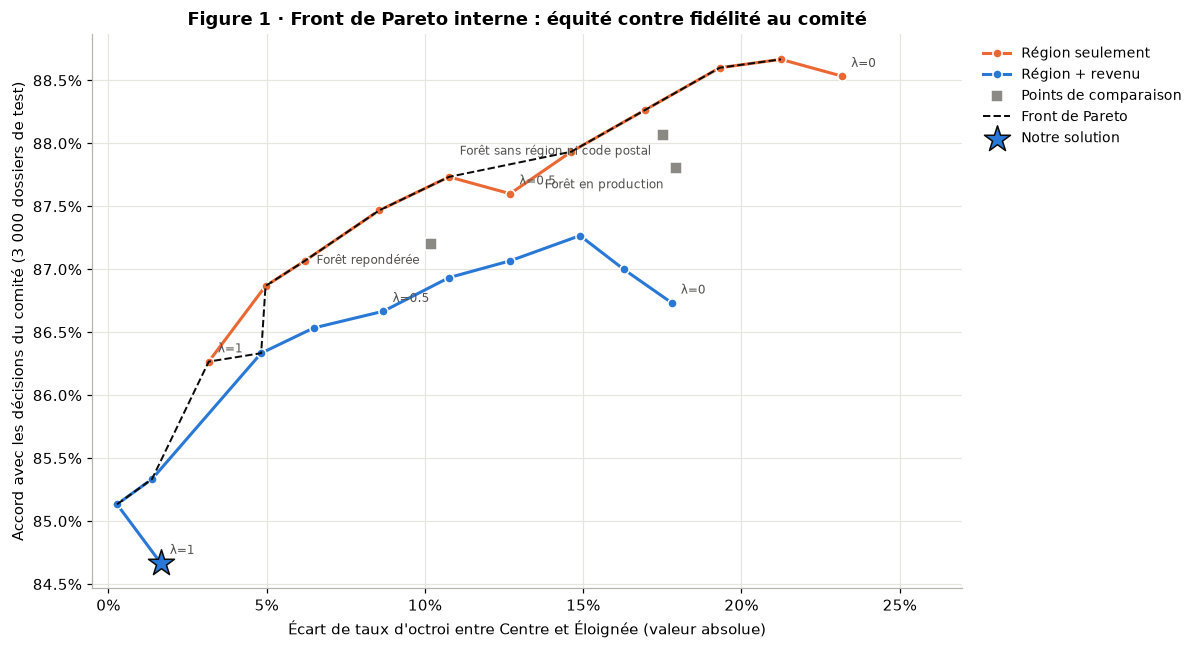

Solutions sur le front de Pareto interne :
        solution  lam_region  ecart_parite  accord_comite
 Région + revenu         0.9         0.003          0.851
 Région + revenu         0.8         0.014          0.853
Région seulement         1.0         0.032          0.863
 Région + revenu         0.7         0.048          0.863
Région seulement         0.9         0.050          0.869
Région seulement         0.8         0.062          0.871
Région seulement         0.7         0.086          0.875
Région seulement         0.6         0.108          0.877
Région seulement         0.4         0.146          0.879
Région seulement         0.3         0.170          0.883
Région seulement         0.2         0.193          0.886
Région seulement         0.1         0.212          0.887


In [9]:
# --- Figure 1 : front de Pareto interne ---
def tracer_pareto(df, y, titre, etiquette_y, fichier, format_y='{:.0%}'):
    fig, ax = plt.subplots(figsize=(11, 6))
    df = df.assign(ecart_abs=df['ecart_parite'].abs())

    # Familles de la correction contrefactuelle
    for (famille, couleur) in [('Région seulement', ORANGE), ('Région + revenu', BLEU)]:
        f = df[df['solution'] == famille].sort_values('lam_region')
        if f.empty:
            continue
        ax.plot(f['ecart_abs'], f[y], '-o', color=couleur, linewidth=2, markersize=6,
                markeredgecolor='white', markeredgewidth=1, label=famille, zorder=3)
        for _, p in f.iterrows():
            if p['lam_region'] in (0, 0.5, 1):
                ax.annotate(f"λ={p['lam_region']:g}", (p['ecart_abs'], p[y]), textcoords='offset points',
                            xytext=(6, 6), fontsize=8, color='#52514e')

    # Points de comparaison
    autres = df[~df['solution'].isin(FAMILLES)]
    if not autres.empty:
        ax.scatter(autres['ecart_abs'], autres[y], marker='s', s=60, color=GRIS,
                   edgecolor='white', zorder=3, label='Points de comparaison')
    for _, p in autres.iterrows():
        ax.annotate(p['solution'], (p['ecart_abs'], p[y]), textcoords='offset points',
                    xytext=(-8, -13), ha='right', fontsize=8, color='#52514e')

    # Front de Pareto
    front = front_pareto(df, 'ecart_parite', y)
    ax.plot(front['_ax'], front[y], '--', color=ENCRE, linewidth=1.3,
            label='Front de Pareto', zorder=5)

    # Notre solution
    nous = df[(df['solution'] == 'Région + revenu') & (df['lam_region'] == 1)]
    if not nous.empty:
        ax.scatter(nous['ecart_abs'], nous[y], marker='*', s=320, color=BLEU,
                   edgecolor=ENCRE, linewidth=1, zorder=4, label='Notre solution')

    ax.set_xlabel("Écart de taux d'octroi entre Centre et Éloignée (valeur absolue)")
    ax.set_ylabel(etiquette_y)
    ax.set_title(titre)
    ax.set_xlim(-0.005, df['ecart_abs'].max() * 1.12 + 0.01)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: format_y.format(v)))
    ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig(fichier, dpi=200, bbox_inches='tight')
    plt.show()
    return front

front_interne = tracer_pareto(
    pareto_interne, 'accord_comite',
    'Figure 1 · Front de Pareto interne : équité contre fidélité au comité',
    'Accord avec les décisions du comité (3 000 dossiers de test)',
    'figures/front_pareto_interne.png', format_y='{:.1%}')

print('Solutions sur le front de Pareto interne :')
print(front_interne[['solution', 'lam_region', 'ecart_parite', 'accord_comite']].round(3).to_string(index=False))

**Comment lire la figure 1 :**

- En haut à droite, la forêt en production et la grille du comité intacte (λ = 0) : elles ressemblent beaucoup au comité, mais l'écart entre régions est grand.
- Plus on retire la pénalité régionale (λ vers 1), plus l'écart se referme, et plus l'accord avec le comité baisse. C'est le compromis classique.
- Retirer la colonne région (forêt sans région ni code postal) ne referme presque pas l'écart : c'est l'effet proxy.
- Le repondérage referme une partie de l'écart, mais moins que la correction contrefactuelle.

**Le piège de cette figure :** l'axe vertical mesure la ressemblance avec un comité biaisé. Une solution juste doit justement s'en éloigner. La baisse d'accord n'est donc pas une « perte » : elle mesure en grande partie les décisions biaisées que nous refusons de reproduire. Pour savoir quelle solution est réellement la meilleure, il faut un juge indépendant du comité : c'est la figure 2.

### Figure 2 : le front contre l'étalon indépendant

La cellule suivante crée un fichier de soumission pour chaque réglage, cette fois sur les 4 000 candidat·es (grille estimée sur les 10 000 dossiers), et les regroupe dans `soumissions_pareto.zip`.

**À faire :**

1. Exécuter la cellule et décompresser `soumissions_pareto.zip`.
2. Soumettre chaque fichier sur HxBuddy (10 fichiers, dont un déjà connu ; maximum 20 soumissions par heure pour l'équipe) et noter le F1 obtenu.
3. Inscrire les F1 dans le dictionnaire `F1_HXBUDDY` de la cellule d'après, puis l'exécuter.

In [10]:
LAMBDAS_SOUMISSION = [0, 0.25, 0.5, 0.75, 1]
os.makedirs('soumissions_pareto', exist_ok=True)

lignes = []
for famille, neutre in FAMILLES.items():
    for lam in LAMBDAS_SOUMISSION:
        dec = decider(proba_contrefactuelle(candidats, lam_region=lam, neutraliser_revenu=neutre))
        assert 0.36 <= dec.mean() <= 0.44
        nom = f"pareto_lam{lam:.2f}_{'region_revenu' if neutre else 'region'}.csv"
        pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': dec}) \
          .to_csv(f'soumissions_pareto/{nom}', index=False)
        lignes.append({'fichier': nom, 'solution': famille, 'lam_region': lam, **mesurer(dec, candidats)})

pareto_candidats = pd.DataFrame(lignes)
shutil.make_archive('soumissions_pareto', 'zip', 'soumissions_pareto')
print(pareto_candidats[['fichier', 'taux_global', 'taux_centre', 'taux_eloignee', 'ecart_parite']]
      .round(3).to_string(index=False))
print('\nFichiers regroupés dans soumissions_pareto.zip')

                         fichier  taux_global  taux_centre  taux_eloignee  ecart_parite
       pareto_lam0.00_region.csv          0.4        0.485          0.276         0.208
       pareto_lam0.25_region.csv          0.4        0.465          0.305         0.161
       pareto_lam0.50_region.csv          0.4        0.448          0.330         0.117
       pareto_lam0.75_region.csv          0.4        0.429          0.357         0.072
       pareto_lam1.00_region.csv          0.4        0.410          0.386         0.024
pareto_lam0.00_region_revenu.csv          0.4        0.469          0.299         0.170
pareto_lam0.25_region_revenu.csv          0.4        0.452          0.324         0.128
pareto_lam0.50_region_revenu.csv          0.4        0.432          0.353         0.079
pareto_lam0.75_region_revenu.csv          0.4        0.411          0.383         0.028
pareto_lam1.00_region_revenu.csv          0.4        0.392          0.412        -0.021

Fichiers regroupés dans soumiss

In [ ]:
# Inscrire ici le F1 obtenu sur HxBuddy pour chaque fichier (0.94 = 94 %).
# Laisser None pour un fichier non soumis : il sera ignoré.
F1_HXBUDDY = {
    'pareto_lam0.00_region.csv':        0.8841,
    'pareto_lam0.25_region.csv':        0.9023,
    'pareto_lam0.50_region.csv':        0.9169,
    'pareto_lam0.75_region.csv':        0.9242,
    'pareto_lam1.00_region.csv':        0.9200,
    'pareto_lam0.00_region_revenu.csv': 0.9054,
    'pareto_lam0.25_region_revenu.csv': 0.9226,
    'pareto_lam0.50_region_revenu.csv': 0.9393,
    'pareto_lam0.75_region_revenu.csv': 0.9424,
    'pareto_lam1.00_region_revenu.csv': 0.9419,   # notre solution (déjà soumise)
}

pareto_etalon = pareto_candidats.assign(f1=pareto_candidats['fichier'].map(F1_HXBUDDY)).dropna(subset=['f1'])

if len(pareto_etalon) >= 3:
    front_etalon = tracer_pareto(
        pareto_etalon, 'f1',
        "Figure 2 · Front de Pareto contre l'étalon indépendant (F1 HxBuddy)",
        'F1 contre l’étalon (HxBuddy)',
        'figures/front_pareto_etalon.png')
    print('Solutions sur le front de Pareto contre l’étalon :')
    print(front_etalon[['fichier', 'ecart_parite', 'f1']].round(3).to_string(index=False))
else:
    print(f'Seulement {len(pareto_etalon)} F1 inscrit(s) : il en faut au moins 3 pour tracer la figure 2.')

**Comment lire la figure 2 et défendre notre choix :**

Contre l'étalon indépendant, le compromis de la figure 1 disparaît : retirer les biais **améliore** à la fois l'équité et la qualité des décisions. Plus λ augmente, plus le F1 monte et plus l'écart entre régions baisse. Les deux objectifs vont dans le même sens, parce que l'étalon, lui, n'est pas biaisé : retirer les biais du comité rapproche nos décisions des bonnes décisions.

Notre solution (λ = 1, région et revenu corrigés) domine toutes les autres : le meilleur F1 (94 %) et le plus petit écart. Le front de Pareto se réduit à ce seul point.

La figure chiffre aussi chacun des deux biais :

- **Retirer la pénalité régionale** fait passer le F1 de 88 % à 92 % (courbe orange, revenu non corrigé).
- **Retirer en plus l'avantage du revenu** ajoute 2 points : de 92 % à 94 % (les deux points λ = 1). Sans cette deuxième correction, nous serions restés à 92 % : c'est la confirmation que le biais du revenu, détecté à la section 3, est réel.
- Sur la courbe bleue, les derniers pas de correction ne changent plus le F1 mais réduisent encore l'écart. Retirer toute la pénalité ne coûte donc rien.

C'est la réponse à la question posée à la fin du carnet de départ : *si l'étiquette est biaisée, le meilleur modèle n'est pas celui qui la prédit le mieux.* La figure 1 récompense la fidélité au comité ; la figure 2 récompense les bonnes décisions. Nous choisissons la seconde.

| Solution testée | F1 HxBuddy |
|---|---|
| LightGBM avec repondérage | 89 % |
| Notre grille, poids des heures de travail modifié (×0, ×0,5, ×1,5, ×2) | 92 à 93 % |
| **Notre grille : région et revenu corrigés (solution retenue)** | **94 %** |

## 8. Test de robustesse : croisements de variables

Notre grille suppose que chaque variable a le même effet pour tout le monde : une heure de travail vaut autant en Gaspésie qu'à Montréal, un point de cote R vaut autant en génie qu'en santé. Est-ce trop simple ? Un **croisement** (ou interaction) permet à l'effet d'une variable de changer selon une autre. S'il existait des croisements importants, notre grille simple passerait à côté.

Nous testons cinq croisements, un à la fois :

| Nom | Croisement | Question posée |
|---|---|---|
| `region_x_heures` | région × heures de travail | Le comité valorisait-il les heures différemment selon la région ? |
| `region_x_coteR` | région × cote R | La pénalité régionale était-elle plus forte pour les dossiers faibles ou forts ? |
| `region_x_revenu` | région × revenu | L'avantage du revenu était-il différent selon la région ? |
| `coteR_x_programme` | cote R × programme | Une même cote R pèse-t-elle autant dans tous les programmes ? |
| `coteR_x_heures` | cote R × heures | Les heures comptent-elles plus quand la cote R est forte ? |

**La correction reste valide avec des croisements.** Au moment de décider, on met `eloignee = 0` et le revenu médian pour tout le monde. Tous les croisements qui contiennent la région tombent donc à zéro d'eux-mêmes : chaque candidat·e est évalué·e avec la grille des grands centres.

Pour chaque variante, on mesure :

1. **La p-valeur du test du rapport de vraisemblance**, qui compare la variante au modèle de base. Sous 0,05, le croisement est réel : il existe dans les décisions du comité. Ce test fonctionne même quand un croisement ajoute plusieurs coefficients (comme cote R × programme).
2. **Le gain d'AUC en validation croisée (5 plis)** : la variante reproduit-elle mieux le comité sur des dossiers qu'elle n'a pas vus ?
3. **La part des décisions qui changent** par rapport à notre solution, sur les 4 000 candidat·es.
4. **Le F1 HxBuddy**, le seul juge indépendant du comité.

Une variante `combinee` réunit tous les croisements réels.

In [ ]:
CROISEMENTS = {
    'region_x_heures':   'eloignee:heures_travail_semaine',
    'region_x_coteR':    'eloignee:cote_r_equivalent',
    'region_x_revenu':   'eloignee:I(revenu_familial_estime / 10000)',
    'coteR_x_programme': 'cote_r_equivalent:C(programme_etudes)',
    'coteR_x_heures':    'cote_r_equivalent:heures_travail_semaine',
}

def auc_validation_croisee(formule, donnees, plis=5):
    # AUC moyenne sur des dossiers jamais vus par le modèle.
    decoupage = StratifiedKFold(n_splits=plis, shuffle=True, random_state=42)
    aucs = []
    for idx_train, idx_test in decoupage.split(donnees, donnees['decision_octroi']):
        tr, te = donnees.iloc[idx_train], donnees.iloc[idx_test]
        m = smf.logit(formule, data=tr).fit(disp=0)
        aucs.append(roc_auc_score(te['decision_octroi'], m.predict(te)))
    return np.mean(aucs)

def evaluer_variante(nom, formule):
    m = smf.logit(formule, data=demandes).fit(disp=0)
    dec = decider(proba_contrefactuelle(candidats, modele=m))
    assert 0.36 <= dec.mean() <= 0.44, f'{nom} : hors enveloppe'
    ligne = {'variante': nom,
             'AUC_validation_croisee': auc_validation_croisee(formule, demandes),
             'decisions_changees': (dec != decision).mean()}
    if nom != 'base':
        stat = 2 * (m.llf - grille_comite.llf)
        ddl = len(m.params) - len(grille_comite.params)
        ligne['p_valeur'] = chi2.sf(stat, ddl)
        coefs = m.params[[c for c in m.params.index if ':' in c]]
        ligne['coefficient(s)'] = ', '.join(f'{v:+.3f}' for v in coefs.values)
    return ligne, dec

os.makedirs('soumissions_croisements', exist_ok=True)
lignes, decisions_croisements = [], {}
variantes = {'base': FORMULE, **{n: FORMULE + ' + ' + t for n, t in CROISEMENTS.items()}}

for nom, formule in variantes.items():
    ligne, dec = evaluer_variante(nom, formule)
    lignes.append(ligne)
    decisions_croisements[nom] = dec

# Variante combinée : tous les croisements réels ensemble
reels = [l['variante'] for l in lignes if l.get('p_valeur', 1) < 0.05]
if len(reels) >= 2:
    ligne, dec = evaluer_variante('combinee', FORMULE + ''.join(' + ' + CROISEMENTS[n] for n in reels))
    ligne['coefficient(s)'] = ' + '.join(reels)
    lignes.append(ligne)
    decisions_croisements['combinee'] = dec

for nom, dec in decisions_croisements.items():
    pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': dec}) \
      .to_csv(f'soumissions_croisements/croisement_{nom}.csv', index=False)

croisements = pd.DataFrame(lignes).set_index('variante')
croisements['gain_AUC'] = croisements['AUC_validation_croisee'] - croisements.loc['base', 'AUC_validation_croisee']
croisements['croisement_reel'] = np.where(croisements['p_valeur'] < 0.05, 'oui', 'non')
croisements.loc['base', 'croisement_reel'] = '-'
if 'combinee' in croisements.index:
    croisements.loc['combinee', 'croisement_reel'] = '-'
print(croisements[['p_valeur', 'croisement_reel', 'coefficient(s)', 'gain_AUC', 'decisions_changees']]
      .round(4).to_string())
print('\nFichiers de soumission écrits dans soumissions_croisements/')

In [ ]:
# F1 obtenus sur HxBuddy pour chaque variante
F1_CROISEMENTS = {
    'base':              0.9419,   # notre solution
    'region_x_heures':   0.9409,
    'region_x_coteR':    0.9419,
    'region_x_revenu':   0.9414,
    'coteR_x_programme': 0.9430,
    'coteR_x_heures':    0.9414,
    'combinee':          0.9409,   # region_x_revenu + coteR_x_heures
}

croisements['F1_HxBuddy'] = pd.Series(F1_CROISEMENTS)
croisements['gain_F1_points'] = 100 * (croisements['F1_HxBuddy'] - F1_CROISEMENTS['base'])
print(croisements[['p_valeur', 'croisement_reel', 'decisions_changees', 'F1_HxBuddy', 'gain_F1_points']]
      .round(4).to_string())

### Ce que montre le test

**Aucun croisement ne justifie de compliquer la grille.** Nous avions fixé la règle avant de regarder les résultats : garder un croisement seulement s'il fait gagner au moins 1 point de F1. Aucun n'y arrive.

- **Les écarts de F1 sont minuscules** : de 94,09 % à 94,30 %, soit au plus 0,2 point de notre solution (94,19 %). Moins de 0,5 % des 4 000 décisions changent, une vingtaine de dossiers au plus.
- **Le seul gain apparent est du bruit.** `coteR_x_programme` donne 94,30 %, mais sa p-valeur (0,71) montre que ce croisement n'existe pas dans les données. Un gain de 0,1 point obtenu par hasard ne se reproduirait pas sur d'autres candidat·es.
- **Les deux croisements réels font baisser le F1.** `region_x_revenu` (p = 0,004) et `coteR_x_heures` (p = 0,003) existent bien dans les décisions du comité, mais ils font baisser le F1 (94,14 %, et 94,09 % combinés). Ils décrivent des habitudes du comité que l'étalon ne partage pas : les reproduire éloigne des bonnes décisions.

**Une facette de plus du biais.** Le croisement `region_x_revenu` est réel : le comité ne traitait pas le revenu de la même façon selon la région (le signe de son coefficient, dans le tableau ci-dessus, indique dans quel sens). Notre correction le retire déjà, puisqu'elle neutralise à la fois la région et le revenu.

**Conclusion :** nous conservons la grille additive. Elle est aussi performante que les variantes plus complexes, plus simple, et plus facile à expliquer à un·e candidat·e (Loi 25). Notre choix d'un modèle simple n'est plus seulement un argument : il est vérifié.

## 9. Chiffres saillants

Phrases prêtes à reprendre dans le rapport et la présentation, calculées à partir des résultats ci-dessus.

In [ ]:
hist = demandes.groupby('groupe')['decision_octroi'].mean()
prod = pareto_interne.set_index('solution').loc['Forêt en production']
sans = pareto_interne.set_index('solution').loc['Forêt sans région ni code postal']
pond = pareto_interne.set_index('solution').loc['Forêt repondérée']
nous = pareto_interne[(pareto_interne['solution'] == 'Région + revenu') & (pareto_interne['lam_region'] == 1)].iloc[0]

print('LE CONSTAT')
print(f"• Le comité accordait la bourse à {hist['Centre']:.1%} des candidat·es des centres, contre {hist['Eloignee']:.1%} en région éloignée.")
print(f"• L'écart réel de cote R moyenne n'est que de {ecart_reel_cote_r:.1f} point.")
print()
print('LE DIAGNOSTIC')
print(f"• À dossier égal, venir d'une région éloignée divisait par {1 / np.exp(b['eloignee']):.0f} les cotes d'obtenir la bourse.")
print(f"• Cette pénalité équivaut à {abs(en_points('eloignee')):.1f} point de cote R, soit {abs(en_points('eloignee')) / ecart_reel_cote_r:.1f} fois l'écart réel de performance.")
print(f"• Chaque 10 000 $ de revenu familial valait {en_points(COL_REVENU):+.2f} point de cote R : 50 000 $ de plus = {5 * en_points(COL_REVENU):+.1f} point.")
print(f"• Retirer la colonne région et le code postal ne réduit l'écart que de {abs(prod['ecart_parite']):.1%} à {abs(sans['ecart_parite']):.1%} : effet proxy.")
print()
print('LA SOLUTION')
print(f"• La régression logistique reproduit le comité presque aussi bien que la forêt (AUC {auc_logit:.3f} contre {auc_foret:.3f}).")
print(f"• Écart entre régions : {abs(prod['ecart_parite']):.1%} (forêt en production) → {abs(pond['ecart_parite']):.1%} (repondérage) → {abs(nous['ecart_parite']):.1%} (notre solution).")
print(f"• Taux d'octroi des 4 000 candidat·es : {decision.mean():.1%} (Centre {taux_groupes['Centre']:.1%}, Éloignée {taux_groupes['Eloignee']:.1%}).")
print(f"• Accord avec le comité : {prod['accord_comite']:.1%} (forêt) → {nous['accord_comite']:.1%} (notre solution) : l'écart correspond surtout aux décisions biaisées que nous refusons de reproduire.")
print('• F1 contre l’étalon : 89 % (LightGBM repondéré) → 94 % (notre solution).')
print('• Contre l’étalon, retirer la pénalité régionale fait passer le F1 de 88 % à 92 % ; retirer aussi l’avantage du revenu le porte à 94 %.')
ecart_max = (croisements['F1_HxBuddy'] - F1_CROISEMENTS['base']).abs().max()
print(f"• {len(CROISEMENTS)} croisements de variables testés : aucun ne change le F1 de plus de {100 * ecart_max:.1f} point. La grille simple est aussi la meilleure.")

## 10. Fichier de soumission `predictions.csv`

In [ ]:
soumission = pd.DataFrame({'id_candidat': candidats['id_candidat'],
                           'decision_octroi': decision})
soumission.to_csv('predictions.csv', index=False)

# Validation du fichier tel qu'il est écrit sur le disque
v = pd.read_csv('predictions.csv')
assert len(v) == 4000, f'Nombre de lignes : {len(v)}'
assert list(v.columns) == ['id_candidat', 'decision_octroi'], 'Colonnes incorrectes'
assert set(v['decision_octroi'].unique()) <= {0, 1}, 'Valeurs autres que 0/1'
assert v['id_candidat'].is_unique, 'Identifiants en double'
assert 0.36 <= v['decision_octroi'].mean() <= 0.44, 'Hors enveloppe'

print(f"✅ predictions.csv valide : {len(v)} lignes, taux d'octroi {v['decision_octroi'].mean():.1%}")

## 11. Limites

- **La grille est une estimation.** La régression logistique suppose des effets réguliers (linéaires sur l'échelle des cotes). Un comité qui combinait les critères de façon plus complexe serait reconstitué moins fidèlement. La section 2 montre que la perte est faible.
- **L'équité est mesurée de façon indirecte.** Sans l'étalon, nous ne pouvons pas calculer exactement l'égalité des chances ; nous nous appuyons sur l'écart à cote R comparable et sur le F1 de HxBuddy.
- **La distance reste dans la grille.** Son effet propre est faible une fois la région prise en compte, mais la distance porte de l'information régionale. Nous avons prévu l'option `neutraliser_distance=True` pour tester la variante qui la neutralise aussi.
- **Le revenu est neutralisé pour la bourse d'excellence.** Pour les prêts d'études, qui reposent sur le besoin, le revenu devrait au contraire jouer en faveur des familles moins aisées. C'est une décision de politique, à prendre par l'institution, pas par le modèle.
- **Les données sont synthétiques** et l'institution est fictive : les chiffres illustrent la méthode.

Le plan de surveillance en production est présenté dans `audit_rapport.ipynb`.